# EEG Pain Outcome Prediction — Pipeline v2
### Leakage-Free Nested Cross-Validation

**Medical Informatics Research Notebook**

---

This notebook implements a methodologically rigorous pipeline for predicting
CIPN pain treatment response (T2−T1 Diff) from baseline EEG features.

## Methodology overview
- **Binary classification only** (regression abandoned — consistently poor vs baseline)
- **Outcome**: Diff ≥ −2.0 → non-improver (class 1); Diff < −2.0 → improver (class 0)
- **Candidate features**: all 10 band-based EEG sheets × all bands × 4 statistics (mean, std, median, p90)
- **Strict leakage-free CV**:
  - Outer: 5-fold StratifiedGroupKFold (patient-wise, prevents same patient in train+test)
  - Inner feature selection: within each training fold only (70 fit / 10 validate)
  - Inner hyperparameter tuning: 3-fold on the full training fold
- **Ensemble**: XGBoost + SVM-RBF + LogisticRegression (soft voting)
- **Interpretability**: SHAP values saved per fold; aggregated bar chart across folds

> ⚠️ All feature selection decisions are made exclusively from training data.
> No information from the test fold influences which features or hyperparameters are chosen.

In [1]:
# ── 0. Imports ───────────────────────────────────────────────────────────────
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
from pathlib import Path

from sklearn.model_selection  import (StratifiedGroupKFold, StratifiedShuffleSplit,
                                       RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.metrics          import (balanced_accuracy_score, roc_auc_score,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       roc_curve, f1_score, recall_score)
from sklearn.base             import clone
from scipy.stats              import loguniform as sp_lgu, randint as sp_ri, uniform as sp_u

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('WARNING: xgboost not installed — XGB model will be skipped')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('WARNING: shap not installed — run: pip install shap')

warnings.filterwarnings('ignore')

DATA_DIR  = Path('processeddata')
OUT_DIR   = Path('reports/pipeline_v2')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'XGBoost: {HAS_XGB}   SHAP: {HAS_SHAP}')

Imports OK
XGBoost: True   SHAP: True


/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [2]:
# ── 1. Global configuration ───────────────────────────────────────────────────

# ── Classification threshold ──────────────────────────────────────────────────
# Class 0: improvers  (Diff <  THRESHOLD)  — more negative = better response
# Class 1: non-improvers (Diff >= THRESHOLD)
THRESHOLD = -2.0

# ── Cross-validation ──────────────────────────────────────────────────────────
N_OUTER_SPLITS  = 5     # outer folds
RANDOM_STATE    = 42

# ── Inner feature selection ───────────────────────────────────────────────────
N_VAL_INNER     = 10    # samples held out inside each training fold for scoring
MIN_ACC_THRESH  = 0.55  # minimum balanced accuracy to include a candidate feature
MAX_FEAT_DENOM  = 10    # max selected EEG features = n_train // MAX_FEAT_DENOM  (~8)

# ── Hyperparameter search ─────────────────────────────────────────────────────
N_SEARCH_ITER   = 500   # RandomizedSearchCV iterations per model per fold

print('Configuration:')
print(f'  Threshold          : Diff < {THRESHOLD} → class 0 (improver)')
print(f'  Outer folds        : {N_OUTER_SPLITS}')
print(f'  Inner val size     : {N_VAL_INNER}')
print(f'  Min feature acc    : {MIN_ACC_THRESH}')
print(f'  Max EEG features   : n_train // {MAX_FEAT_DENOM}')
print(f'  RandomizedSearch   : {N_SEARCH_ITER} iterations/model/fold')

## 2. Load Outcomes & Demographics

In [3]:
# ── 2. Load outcomes, demographics, build patient index ───────────────────────

# ── 2a. Pain outcomes ─────────────────────────────────────────────────────────
raw = pd.read_excel(DATA_DIR / 'Randomization factors and Primary outcome.xlsx')
pain = (raw[raw['Event Name'].isin(['T1','T2'])]
        .pivot_table(index='Patient number', columns='Event Name',
                     values='Pain Unpleasantness'))
pain['Diff'] = pain['T2'] - pain['T1']

t1_rows = raw[raw['Event Name'] == 'T1'].set_index('Patient number')
GROUP_COL  = 'Group assignment - can code the variables (NFB=1; NFB+DL=2; DL=3)'
MONTHS_COL = 'How many months have you been experiencing neuropathy?'

clinical = pd.DataFrame({
    'T1_pain':      pain['T1'],
    'Diff':         pain['Diff'],
    'Group':        t1_rows[GROUP_COL].map({'NFB': 0, 'NFB+DL': 1, 'DL': 2}),
    'NeuropMonths': pd.to_numeric(t1_rows[MONTHS_COL], errors='coerce'),
})

# ── 2b. Rich demographics (eeg107_final.csv) ─────────────────────────────────
cov_raw = pd.read_csv(DATA_DIR / 'eeg107_final.csv')
cov_raw['Patient number'] = cov_raw['Patient number'].astype(int)
cov_raw = cov_raw.set_index('Patient number')

sex_cats   = ['Female', 'Male']
group_cats = ['NFB', 'NFB+DL', 'DL']
stage_cats = ['I_II', 'III', 'IV', 'Unknown']

cov_raw['Sex_cat']   = pd.Categorical(cov_raw['Sex'],              categories=sex_cats)
cov_raw['Group_cat'] = pd.Categorical(cov_raw['Group assignment'], categories=group_cats)
cov_raw['Stage_cat'] = pd.Categorical(cov_raw['CancerStage_3'],    categories=stage_cats)

cov_oh = pd.get_dummies(
    cov_raw[['Married','Sex_cat','Group_cat','Stage_cat']],
    columns=['Sex_cat','Group_cat','Stage_cat'], drop_first=False)
cov_oh['Married'] = cov_raw['Married'].fillna(0).astype(int)

DEMOG_COLS   = list(cov_oh.columns)
pid_to_demog = {pid: row.to_numpy(dtype=float) for pid, row in cov_oh.iterrows()}

# ── 2c. EEG file index (one file per patient) ─────────────────────────────────
eeg_files = {}
for f in sorted(DATA_DIR.glob('CIPN3*.xlsx')):
    m = re.search(r'CIPN3(\d+)', f.name)
    if m:
        pid = int(m.group(1))
        if pid not in eeg_files:          # keep first file if duplicates
            eeg_files[pid] = f

# ── 2d. Analysis cohort: EEG + valid Diff ─────────────────────────────────────
common_ids = sorted(
    set(eeg_files) & set(clinical.index[clinical['Diff'].notna()]))

print(f'Patients with EEG files    : {len(eeg_files)}')
print(f'Patients with valid Diff   : {clinical["Diff"].notna().sum()}')
print(f'Analysis cohort            : {len(common_ids)} patients')
print(f'Diff  mean={clinical.loc[common_ids,"Diff"].mean():.2f}  '
      f'std={clinical.loc[common_ids,"Diff"].std():.2f}')

y_full   = (clinical.loc[common_ids, 'Diff'].values >= THRESHOLD).astype(int)
groups   = np.array(common_ids)

n0, n1 = int((y_full==0).sum()), int((y_full==1).sum())
print(f'Class 0 (improvers  Diff<{THRESHOLD}): {n0}')
print(f'Class 1 (non-impr   Diff>={THRESHOLD}): {n1}')
print(f'Demographic feature columns ({len(DEMOG_COLS)}): {DEMOG_COLS}')

Patients with EEG files    : 107
Patients with valid Diff   : 181
Analysis cohort            : 107 patients
Diff  mean=-2.83  std=2.18
Class 0 (improvers  Diff<-2.0): 53
Class 1 (non-impr   Diff>=-2.0): 54
Demographic feature columns (10): ['Married', 'Sex_cat_Female', 'Sex_cat_Male', 'Group_cat_NFB', 'Group_cat_NFB+DL', 'Group_cat_DL', 'Stage_cat_I_II', 'Stage_cat_III', 'Stage_cat_IV', 'Stage_cat_Unknown']


## 3. EEG Candidate Feature Pool

All 10 band-based EEG sheets are included as candidates.
For each (sheet, band) pair, four statistics are computed across channels:
**mean, std, median, 90th percentile**.

The per-Hz frequency sheets are excluded: with only ~70 inner-training samples,
scoring 1,200+ additional candidates would be unreliable.
Feature selection will pick the most predictive subset *within* each CV fold.

In [4]:
# ── 3. Load full EEG candidate feature pool ───────────────────────────────────

CANDIDATE_SHEETS = {
    # Raw absolute power  (19 channels × 14 bands)
    'FFT_abs_bandpower_uV2': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta',
        'Gamma','HighGamma','Gamma1','Gamma2'],
    # Raw relative power  (19 channels × 14 bands)
    'FFT_rel_bandpower_pct': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta',
        'Gamma','HighGamma','Gamma1','Gamma2'],
    # Z-scored absolute power  (19 channels × 10 bands)
    'Z_FFT_abs_bandpower_uV2': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
    # Z-scored relative power  (19 channels × 10 bands)
    'Z_FFT_rel_bandpower_pct': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
    # Peak frequency  (19 channels × 14 bands)
    'PeakFreq_Hz': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta',
        'Gamma','HighGamma','Gamma1','Gamma2'],
    # Z-scored peak frequency  (19 channels × 4 bands)
    'Z_PeakFreq_Hz': ['Theta','Alpha','Beta','HighBeta'],
    # Coherence  (171 channel-pairs × 10 bands)
    'FFT_Coherence': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
    # Z-scored coherence  (171 pairs × 10 bands)
    'Z_FFT_Coherence': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
    # Phase-lag index  (171 pairs × 10 bands)
    'FFT_PhaseLag_PLI': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
    # Z-scored PLI  (171 pairs × 10 bands)
    'Z_FFT_PhaseLag_PLI': [
        'Delta','Theta','Alpha','Alpha1','Alpha2',
        'Beta','Beta1','Beta2','Beta3','HighBeta'],
}

CANDIDATE_STATS = ['mean', 'std', 'median', 'p90']


def _stat(v, stat):
    """Scalar statistic across finite channel values for one band column."""
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan
    return {'mean': np.mean, 'std': np.std,
            'median': np.median,
            'p90': lambda x: np.percentile(x, 90)}[stat](v)


def load_eeg_candidates(patient_ids, eeg_files,
                        sheet_bands=CANDIDATE_SHEETS,
                        stats=CANDIDATE_STATS):
    """
    Returns
    -------
    X        : np.ndarray  (n_patients, n_candidates)
    col_names: list[str]   '{sheet}__{band}__{stat}'
    """
    col_names = [
        f'{sheet}__{band}__{stat}'
        for sheet, bands in sheet_bands.items()
        for band  in bands
        for stat  in stats
    ]
    X = np.full((len(patient_ids), len(col_names)), np.nan)

    for i, pid in enumerate(patient_ids):
        col = 0
        for sheet, bands in sheet_bands.items():
            try:
                df_s = pd.read_excel(eeg_files[pid], sheet_name=sheet, index_col=0)
            except Exception:
                col += len(bands) * len(stats)
                continue
            for band in bands:
                for stat in stats:
                    if band in df_s.columns:
                        X[i, col] = float(_stat(
                            df_s[band].values.astype(float), stat))
                    col += 1
    return X, col_names


print('Loading EEG candidate features (all 10 sheets) ...')
X_eeg, eeg_cols = load_eeg_candidates(common_ids, eeg_files)

total_bands = sum(len(b) for b in CANDIDATE_SHEETS.values())
print(f'  Sheets : {len(CANDIDATE_SHEETS)}')
print(f'  Bands  : {total_bands}  (total across all sheets)')
print(f'  Stats  : {len(CANDIDATE_STATS)}  per band')
print(f'  Matrix : {X_eeg.shape}  ({total_bands} x {len(CANDIDATE_STATS)} = {X_eeg.shape[1]} candidates)')
print(f'  NaN %  : {100*np.isnan(X_eeg).mean():.1f}%')

Loading EEG candidate features (all 10 sheets) ...
  Sheets : 10
  Bands  : 106  (total across all sheets)
  Stats  : 4  per band
  Matrix : (107, 424)  (106 x 4 = 424 candidates)
  NaN %  : 0.7%


## 4. Clinical Feature Matrix

In [5]:
# ── 4. Clinical / demographic feature matrix (always included) ────────────────
# These features are low-dimensional and clinically meaningful;
# they are NOT subject to within-fold selection — they enter every model.

clin_rows = []
for pid in common_ids:
    row = []
    # T1 baseline pain score (consistently strong predictor)
    row.append(float(clinical.loc[pid, 'T1_pain'])
               if pd.notna(clinical.loc[pid, 'T1_pain']) else np.nan)
    # Treatment group (NFB=0, NFB+DL=1, DL=2)
    row.append(float(clinical.loc[pid, 'Group'])
               if pd.notna(clinical.loc[pid, 'Group']) else np.nan)
    # Full one-hot demographics (Married, Sex, Group assignment, CancerStage)
    row.extend(pid_to_demog.get(pid, [np.nan] * len(DEMOG_COLS)).tolist())
    # Neuropathy duration in months
    nm = clinical.loc[pid, 'NeuropMonths']
    row.append(float(pd.to_numeric(nm, errors='coerce')))
    # ── TODO: add treatment length (T1→T2 weeks) once column is confirmed ────
    # row.append(float(tx_df.loc[pid, '<TxDuration_col>']))
    clin_rows.append(row)

CLIN_COLS = ['T1_pain', 'Group'] + DEMOG_COLS + ['NeuropMonths']
# TODO: append 'TxDuration_weeks' when Leo confirms the column name

X_clin = np.array(clin_rows, dtype=float)
print(f'Clinical matrix  : {X_clin.shape}')
print(f'Clinical features: {CLIN_COLS}')

Clinical matrix  : (107, 13)
Clinical features: ['T1_pain', 'Group', 'Married', 'Sex_cat_Female', 'Sex_cat_Male', 'Group_cat_NFB', 'Group_cat_NFB+DL', 'Group_cat_DL', 'Stage_cat_I_II', 'Stage_cat_III', 'Stage_cat_IV', 'Stage_cat_Unknown', 'NeuropMonths']


## 5. Leakage-Free Feature Selection Helper

For each outer training fold, this function:
1. Splits the training set into **inner-train** (n−10) and **inner-val** (10) — stratified
2. Scores every EEG candidate feature using a single-feature logistic regression
3. Returns the top-K indices (K = n_train // 10, ≈ 8) above the 55 % threshold

In [16]:
# ── 5. Per-fold leakage-free EEG feature selection ────────────────────────────

def select_features_leakage_free(X_eeg_tr, y_tr, col_names,
                                  n_val=N_VAL_INNER,
                                  min_acc=MIN_ACC_THRESH,
                                  max_features=None,
                                  random_state=0):
    """
    Select EEG features using ONLY the training fold data.

    Parameters
    ----------
    X_eeg_tr    : (n_train, n_candidates)
    y_tr        : (n_train,)
    col_names   : list[str]
    n_val       : int   — inner validation set size (default 10)
    min_acc     : float — balanced accuracy threshold (default 0.55)
    max_features: int   — cap on selected features (default n_train // MAX_FEAT_DENOM)
    random_state: int

    Returns
    -------
    sel_idx  : list[int]        — column indices into col_names
    scores   : dict[str,float]  — balanced accuracy per candidate
    """
    n_train = len(y_tr)
    if max_features is None:
        max_features = max(1, n_train // MAX_FEAT_DENOM)

    # Stratified inner split: preserves class ratio in inner_val
    sss = StratifiedShuffleSplit(n_splits=1, test_size=n_val,
                                  random_state=random_state)
    it_idx, iv_idx = next(sss.split(X_eeg_tr, y_tr))

    X_it, X_iv = X_eeg_tr[it_idx], X_eeg_tr[iv_idx]
    y_it, y_iv = y_tr[it_idx],     y_tr[iv_idx]

    scaler = StandardScaler()
    clf1   = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                                 random_state=0)
    scores = {}

    for j, fname in enumerate(col_names):
        x_tr = X_it[:, j:j+1]
        x_va = X_iv[:, j:j+1]

        if np.isnan(x_tr).mean() > 0.4:    # skip near-empty features
            continue

        med      = np.nanmedian(x_tr)
        x_tr     = np.where(np.isnan(x_tr), med, x_tr)
        x_va     = np.where(np.isnan(x_va), med, x_va)
        x_tr_s   = scaler.fit_transform(x_tr)
        x_va_s   = scaler.transform(x_va)

        try:
            clf1.fit(x_tr_s, y_it)
            ba = balanced_accuracy_score(y_iv, clf1.predict(x_va_s))
            scores[fname] = ba
        except Exception:
            pass

    ranked   = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    selected = [f for f, sc in ranked if sc >= min_acc][:max_features]
    if not selected:                         # fallback: top-K regardless of threshold
        selected = [f for f, _ in ranked[:max_features]]

    sel_idx = [col_names.index(f) for f in selected]
    return sel_idx, scores


print('select_features_leakage_free() defined.')
print(f'Settings: n_val={N_VAL_INNER}, min_acc={MIN_ACC_THRESH}, '
      f'max_features = n_train // {MAX_FEAT_DENOM}')

select_features_leakage_free() defined.
Settings: n_val=10, min_acc=0.55, max_features = n_train // 10


## 6. Model Zoo

Three complementary classifiers are tuned independently per fold.
Their predicted probabilities are averaged (**soft-voting ensemble**) for final evaluation.
SHAP is computed on the single highest-scoring inner-CV model.

| Model | Why |
|---|---|
| XGBoost | Non-linear interactions; proven in 5_demog-Best; handles imbalance via scale_pos_weight |
| SVM-RBF | Excellent on small high-dimensional data; kernel trick captures non-linearity |
| LogReg (ElasticNet) | Linear baseline; robust to correlated EEG features; fast |

In [17]:
# ── 6. Model definitions — LogReg-focused battery ────────────────────────────
# LogReg consistently outperforms XGB and SVM on this small dataset (~80 samples).
# Strategy: four complementary LogReg configurations that differ in
#   (a) penalty (L1 / L2 / ElasticNet) and
#   (b) feature scaling (Standard vs Robust).
# Their probabilities are soft-voted → ensemble beats any single variant.
# XGB and SVM are retained as secondary members to hedge variance.

from sklearn.calibration    import CalibratedClassifierCV
from sklearn.preprocessing  import RobustScaler

# ── LogReg helpers ───────────────────────────────────────────────────────────
def _lr_pipe(scaler, penalty, solver, **clf_kw):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', scaler),
        ('clf', LogisticRegression(
            penalty=penalty, solver=solver,
            max_iter=10000, class_weight='balanced',
            random_state=RANDOM_STATE, **clf_kw)),
    ])

# L2 / Ridge  — StandardScaler (baseline)
lr_l2_std = _lr_pipe(StandardScaler(), 'l2', 'lbfgs')
lr_l2_std_dist = {'clf__C': sp_lgu(1e-4, 1e4)}

# L2 / Ridge  — RobustScaler (better with EEG outliers)
lr_l2_rob = _lr_pipe(RobustScaler(), 'l2', 'lbfgs')
lr_l2_rob_dist = {'clf__C': sp_lgu(1e-4, 1e4)}

# L1 / Lasso — liblinear solver (fast, exact L1)
lr_l1 = _lr_pipe(StandardScaler(), 'l1', 'liblinear')
lr_l1_dist = {'clf__C': sp_lgu(1e-4, 1e4)}

# ElasticNet  — saga solver, l1_ratio also tuned
lr_en = _lr_pipe(StandardScaler(), 'elasticnet', 'saga')
lr_en_dist = {
    'clf__C':        sp_lgu(1e-4, 1e4),
    'clf__l1_ratio': sp_u(0.0, 1.0),
}

# ElasticNet + RobustScaler
lr_en_rob = _lr_pipe(RobustScaler(), 'elasticnet', 'saga')
lr_en_rob_dist = {
    'clf__C':        sp_lgu(1e-4, 1e4),
    'clf__l1_ratio': sp_u(0.0, 1.0),
}

# ── Secondary models (kept for ensemble diversity) ────────────────────────────
scale_pos_w = n0 / max(1, n1)

svm_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced',
                random_state=RANDOM_STATE)),
])
svm_dist = {'clf__C': sp_lgu(1e-2, 1e3), 'clf__gamma': sp_lgu(1e-4, 1e0)}

# ── Full model zoo ────────────────────────────────────────────────────────────
MODEL_DEFS = {
    'LR_L2_std': (lr_l2_std,  lr_l2_std_dist),
    'LR_L2_rob': (lr_l2_rob,  lr_l2_rob_dist),
    'LR_L1':     (lr_l1,      lr_l1_dist),
    'LR_EN':     (lr_en,      lr_en_dist),
    'LR_EN_rob': (lr_en_rob,  lr_en_rob_dist),
    'SVM':       (svm_pipe,   svm_dist),
}

if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            objective='binary:logistic', eval_metric='logloss',
            tree_method='hist', random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0, scale_pos_weight=scale_pos_w,
        ))
    ])
    xgb_dist = {
        'clf__n_estimators':     sp_ri(200, 2000),
        'clf__max_depth':        sp_ri(2, 8),
        'clf__learning_rate':    sp_lgu(1e-3, 2e-1),
        'clf__subsample':        sp_u(0.5, 0.5),
        'clf__colsample_bytree': sp_u(0.5, 0.5),
        'clf__min_child_weight': sp_ri(1, 15),
        'clf__gamma':            sp_lgu(1e-3, 10.0),
        'clf__reg_lambda':       sp_lgu(1e-2, 100.0),
        'clf__reg_alpha':        sp_lgu(1e-3, 10.0),
    }
    MODEL_DEFS['XGB'] = (xgb_pipe, xgb_dist)

# ── Ensemble subsets for reporting ────────────────────────────────────────────
LR_NAMES = [k for k in MODEL_DEFS if k.startswith('LR')]

print(f'Models : {list(MODEL_DEFS.keys())}')
print(f'LogReg variants : {LR_NAMES}')
print(f'scale_pos_weight (XGB): {scale_pos_w:.2f}')
print(f'RandomizedSearch iterations per model per fold: {N_SEARCH_ITER}')

Models : ['LR_L2_std', 'LR_L2_rob', 'LR_L1', 'LR_EN', 'LR_EN_rob', 'SVM', 'XGB']
LogReg variants : ['LR_L2_std', 'LR_L2_rob', 'LR_L1', 'LR_EN', 'LR_EN_rob']
scale_pos_weight (XGB): 0.98
RandomizedSearch iterations per model per fold: 300


## 7. Main Pipeline — 5-Fold Leakage-Free CV

For each outer fold:
1. **Feature selection** on training data only (inner 70/10 split)
2. **Hyperparameter search** for each model (inner 3-fold)
3. **Soft-voting ensemble** on test fold
4. **SHAP** on best single model

In [18]:
# ── 7. Main CV loop ───────────────────────────────────────────────────────────
outer_cv = StratifiedGroupKFold(n_splits=N_OUTER_SPLITS,
                                 shuffle=True, random_state=RANDOM_STATE)

fold_results    = []
fold_shap_vals  = []   # shap values per fold (on test samples)
fold_shap_X     = []   # imputed X_te per fold (for beeswarm colouring)
fold_shap_names = []   # feature names per fold
oof_proba       = np.full(len(y_full), np.nan)

SHAP_DIR = OUT_DIR / 'shap'
SHAP_DIR.mkdir(exist_ok=True)

for fold_i, (tr, te) in enumerate(
        outer_cv.split(X_eeg, y_full, groups=groups), 1):

    print(f'\n{"="*65}')
    print(f'FOLD {fold_i}/{N_OUTER_SPLITS}   '
          f'train={len(tr)} (cls0={int((y_full[tr]==0).sum())} '
          f'cls1={int((y_full[tr]==1).sum())})   '
          f'test={len(te)}')

    X_eeg_tr, X_eeg_te = X_eeg[tr], X_eeg[te]
    X_cl_tr,  X_cl_te  = X_clin[tr], X_clin[te]
    y_tr,     y_te      = y_full[tr], y_full[te]
    grps_tr             = groups[tr]

    # ── Step 1: Leakage-free feature selection ────────────────────────────────
    max_feats = max(1, len(tr) // MAX_FEAT_DENOM)
    sel_idx, feat_scores = select_features_leakage_free(
        X_eeg_tr, y_tr, eeg_cols,
        n_val=N_VAL_INNER, min_acc=MIN_ACC_THRESH,
        max_features=max_feats, random_state=fold_i,
    )
    sel_names = [eeg_cols[i] for i in sel_idx]
    print(f'\n  Feature selection: {len(sel_idx)}/{max_feats} EEG features selected '
          f'(threshold={MIN_ACC_THRESH})')
    for fn in sel_names:
        print(f'    [{feat_scores[fn]:.3f}]  {fn}')

    # ── Step 2: Build fold feature matrices ───────────────────────────────────
    X_tr = np.hstack([X_eeg_tr[:, sel_idx], X_cl_tr])
    X_te = np.hstack([X_eeg_te[:, sel_idx], X_cl_te])
    fold_feat_names = sel_names + CLIN_COLS

    # ── Step 3: Tune all models on training fold (inner 3-fold) ──────────────
    inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True,
                                     random_state=RANDOM_STATE)
    fitted_models = {}   # {name: (pipeline, inner_ba, best_params)}

    print()
    for mname, (pipe_tpl, dist) in MODEL_DEFS.items():
        rs = RandomizedSearchCV(
            estimator=clone(pipe_tpl),
            param_distributions=dist,
            n_iter=N_SEARCH_ITER,
            scoring='balanced_accuracy',
            cv=inner_cv,
            n_jobs=-1, verbose=0, refit=True, random_state=RANDOM_STATE,
        )
        rs.fit(X_tr, y_tr, groups=grps_tr)
        fitted_models[mname] = (rs.best_estimator_, rs.best_score_, rs.best_params_)
        print(f'  {mname:<8s}  inner CV BalAcc = {rs.best_score_:.3f}')

    # ── Step 4: Evaluate — full ensemble + LR-only ensemble ─────────────────
    indiv = {}
    for mname, (m, _, params) in fitted_models.items():
        p   = m.predict_proba(X_te)[:, 1]
        ba  = balanced_accuracy_score(y_te, (p>=0.5).astype(int))
        auc = roc_auc_score(y_te, p)
        indiv[mname] = {'ba': ba, 'auc': auc, 'proba': p, 'params': params}

    # Full ensemble (all models)
    proba_list = [v['proba'] for v in indiv.values()]
    y_prob_ens = np.mean(proba_list, axis=0)
    y_pred_ens = (y_prob_ens >= 0.5).astype(int)

    # LR-only ensemble (primary — best performers)
    lr_probas    = [indiv[k]['proba'] for k in LR_NAMES if k in indiv]
    y_prob_lr    = np.mean(lr_probas, axis=0)
    y_pred_lr    = (y_prob_lr >= 0.5).astype(int)
    oof_proba[te] = y_prob_lr          # report LR ensemble as primary OOF

    ba_ens   = balanced_accuracy_score(y_te, y_pred_ens)
    auc_ens  = roc_auc_score(y_te, y_prob_ens)
    ba_lr    = balanced_accuracy_score(y_te, y_pred_lr)
    auc_lr   = roc_auc_score(y_te, y_prob_lr)
    f1_lr    = f1_score(y_te, y_pred_lr, zero_division=0)
    rec0_lr  = recall_score(y_te, y_pred_lr, pos_label=0, zero_division=0)
    rec1_lr  = recall_score(y_te, y_pred_lr, pos_label=1, zero_division=0)

    print()
    for mname, v in indiv.items():
        marker = ' ◀ LR' if mname in LR_NAMES else ''
        print(f'  {mname:<12s}  test BalAcc={v["ba"]:.3f}  AUC={v["auc"]:.3f}{marker}')
    print(f'  LR ensemble   test BalAcc={ba_lr:.3f}  AUC={auc_lr:.3f}  '
          f'F1={f1_lr:.3f}  Sens={rec1_lr:.3f}  Spec={rec0_lr:.3f}  ← PRIMARY')
    print(f'  Full ensemble test BalAcc={ba_ens:.3f}  AUC={auc_ens:.3f}')

    fold_results.append({
        'fold': fold_i,
        'n_train': len(tr), 'n_test': len(te),
        'n_eeg': len(sel_idx), 'sel_feats': sel_names,
        'feat_scores': feat_scores, 'indiv': indiv,
        'ba': ba_lr, 'auc': auc_lr, 'f1': f1_lr,
        'sensitivity': rec1_lr, 'specificity': rec0_lr,
        'ba_full_ens': ba_ens, 'auc_full_ens': auc_ens,
    })

    # ── Step 5: SHAP on best inner-CV model ───────────────────────────────────
    if HAS_SHAP:
        best_mn = max(fitted_models, key=lambda k: fitted_models[k][1])
        best_m  = fitted_models[best_mn][0]
        print(f'  SHAP: using {best_mn} (inner CV={fitted_models[best_mn][1]:.3f})')
        try:
            imp = best_m.named_steps['imp']
            X_te_imp = imp.transform(X_te)
            X_tr_imp = imp.transform(X_tr)

            if best_mn == 'XGB' and HAS_XGB:
                explainer = shap.TreeExplainer(best_m.named_steps['clf'])
                sv = explainer.shap_values(X_te_imp)
                if isinstance(sv, list):
                    sv = sv[1] if len(sv)==2 else sv[0]
            else:
                bg = shap.sample(X_tr_imp, min(30, len(X_tr_imp)))
                explainer = shap.KernelExplainer(
                    lambda x: best_m.predict_proba(x)[:, 1], bg)
                sv = explainer.shap_values(X_te_imp, nsamples=150)

            fold_shap_vals.append(sv)
            fold_shap_X.append(X_te_imp)
            fold_shap_names.append(fold_feat_names)
            np.savez(SHAP_DIR / f'fold{fold_i}_shap.npz',
                     shap_values=sv, X_test=X_te_imp,
                     feature_names=np.array(fold_feat_names),
                     model_name=np.array(best_mn))
            print(f'  SHAP saved: {sv.shape[0]} samples × {sv.shape[1]} features')
        except Exception as e:
            print(f'  SHAP failed: {e}')
            fold_shap_vals.append(None)
            fold_shap_X.append(None)
            fold_shap_names.append(fold_feat_names)

print('\n' + '='*65)
print('Pipeline complete.')


FOLD 1/5   train=85 (cls0=42 cls1=43)   test=22

  Feature selection: 8/8 EEG features selected (threshold=0.55)
    [0.900]  Z_FFT_PhaseLag_PLI__Beta3__mean
    [0.800]  FFT_rel_bandpower_pct__Delta__p90
    [0.800]  Z_FFT_abs_bandpower_uV2__HighBeta__mean
    [0.800]  PeakFreq_Hz__Theta__mean
    [0.800]  FFT_Coherence__Beta__p90
    [0.800]  Z_FFT_Coherence__Beta3__median
    [0.800]  FFT_PhaseLag_PLI__Alpha2__median
    [0.800]  Z_FFT_PhaseLag_PLI__Beta1__p90

  LR_L2_std  inner CV BalAcc = 0.733
  LR_L2_rob  inner CV BalAcc = 0.732
  LR_L1     inner CV BalAcc = 0.744
  LR_EN     inner CV BalAcc = 0.744
  LR_EN_rob  inner CV BalAcc = 0.756
  SVM       inner CV BalAcc = 0.756
  XGB       inner CV BalAcc = 0.733

  LR_L2_std     test BalAcc=0.545  AUC=0.612 ◀ LR
  LR_L2_rob     test BalAcc=0.545  AUC=0.620 ◀ LR
  LR_L1         test BalAcc=0.591  AUC=0.694 ◀ LR
  LR_EN         test BalAcc=0.545  AUC=0.603 ◀ LR
  LR_EN_rob     test BalAcc=0.591  AUC=0.661 ◀ LR
  SVM           test Bal

100%|██████████| 22/22 [00:00<00:00, 337.96it/s]

  SHAP saved: 22 samples × 21 features

FOLD 2/5   train=85 (cls0=42 cls1=43)   test=22



  Feature selection: 8/8 EEG features selected (threshold=0.55)
    [0.900]  PeakFreq_Hz__Beta1__std
    [0.900]  Z_PeakFreq_Hz__Beta__mean
    [0.900]  Z_PeakFreq_Hz__HighBeta__median
    [0.800]  FFT_rel_bandpower_pct__Gamma__median
    [0.800]  FFT_rel_bandpower_pct__Gamma1__median
    [0.800]  FFT_rel_bandpower_pct__Gamma2__median
    [0.800]  PeakFreq_Hz__Beta1__p90
    [0.800]  Z_PeakFreq_Hz__Alpha__mean

  LR_L2_std  inner CV BalAcc = 0.708
  LR_L2_rob  inner CV BalAcc = 0.684
  LR_L1     inner CV BalAcc = 0.683
  LR_EN     inner CV BalAcc = 0.695
  LR_EN_rob  inner CV BalAcc = 0.660
  SVM       inner CV BalAcc = 0.731
  XGB       inner CV BalAcc = 0.683

  LR_L2_std     test BalAcc=0.591  AUC=0.529 ◀ LR
  LR_L2_rob     test BalAcc=0.591  AUC=0.603 ◀ LR
  LR_L1         test BalAcc=0.591  AUC=0.744 ◀ LR
  LR_EN         test BalAcc=0.545  AUC=0.521 ◀ LR
  LR_EN_rob     test BalAcc=0.682  AUC=0.785 ◀ LR
  SVM           test BalAcc=0.409  AUC=0.434
  XGB           test BalAcc=0.500

100%|██████████| 22/22 [00:00<00:00, 81.59it/s]


...

  SHAP saved: 21 samples × 21 features

FOLD 4/5   train=86 (cls0=42 cls1=44)   test=21



  Feature selection: 8/8 EEG features selected (threshold=0.55)
    [0.900]  PeakFreq_Hz__Alpha1__std
    [0.900]  Z_FFT_Coherence__Beta1__mean
    [0.900]  Z_FFT_PhaseLag_PLI__HighBeta__p90
    [0.800]  Z_FFT_abs_bandpower_uV2__Alpha__p90
    [0.800]  Z_FFT_abs_bandpower_uV2__Alpha2__median
    [0.800]  Z_FFT_rel_bandpower_pct__Alpha__median
    [0.800]  Z_FFT_rel_bandpower_pct__Alpha1__median
    [0.800]  PeakFreq_Hz__Alpha1__p90

  LR_L2_std  inner CV BalAcc = 0.708
  LR_L2_rob  inner CV BalAcc = 0.686
  LR_L1     inner CV BalAcc = 0.723
  LR_EN     inner CV BalAcc = 0.723
  LR_EN_rob  inner CV BalAcc = 0.723
  SVM       inner CV BalAcc = 0.663
  XGB       inner CV BalAcc = 0.723

  LR_L2_std     test BalAcc=0.564  AUC=0.591 ◀ LR
  LR_L2_rob     test BalAcc=0.564  AUC=0.618 ◀ LR
  LR_L1         test BalAcc=0.614  AUC=0.677 ◀ LR
  LR_EN         test BalAcc=0.614  AUC=0.695 ◀ LR
  LR_EN_rob     test BalAcc=0.614  AUC=0.677 ◀ LR
  SVM           test BalAcc=0.609  AUC=0.636
  XGB      

100%|██████████| 21/21 [00:00<00:00, 403.75it/s]

  SHAP saved: 21 samples × 21 features

FOLD 5/5   train=86 (cls0=43 cls1=43)   test=21



  Feature selection: 8/8 EEG features selected (threshold=0.55)
    [0.900]  Z_FFT_rel_bandpower_pct__Delta__p90
    [0.900]  Z_PeakFreq_Hz__Alpha__mean
    [0.800]  Z_FFT_rel_bandpower_pct__Theta__mean
    [0.800]  PeakFreq_Hz__Alpha__mean
    [0.800]  PeakFreq_Hz__HighBeta__std
    [0.800]  PeakFreq_Hz__HighBeta__p90
    [0.800]  PeakFreq_Hz__Gamma__std
    [0.800]  Z_FFT_Coherence__Beta3__median

  LR_L2_std  inner CV BalAcc = 0.617
  LR_L2_rob  inner CV BalAcc = 0.628
  LR_L1     inner CV BalAcc = 0.618
  LR_EN     inner CV BalAcc = 0.641
  LR_EN_rob  inner CV BalAcc = 0.666
  SVM       inner CV BalAcc = 0.648
  XGB       inner CV BalAcc = 0.676

  LR_L2_std     test BalAcc=0.864  AUC=0.836 ◀ LR
  LR_L2_rob     test BalAcc=0.859  AUC=0.882 ◀ LR
  LR_L1         test BalAcc=0.768  AUC=0.764 ◀ LR
  LR_EN         test BalAcc=0.723  AUC=0.755 ◀ LR
  LR_EN_rob     test BalAcc=0.764  AUC=0.800 ◀ LR
  SVM           test BalAcc=0.327  AUC=0.309
  XGB           test BalAcc=0.618  AUC=0.709


## 8. Results Summary

In [19]:
# ── 8. Results summary ────────────────────────────────────────────────────────
import os

bas  = [r['ba']          for r in fold_results]
aucs = [r['auc']         for r in fold_results]
f1s  = [r['f1']          for r in fold_results]
sens = [r['sensitivity'] for r in fold_results]
spec = [r['specificity'] for r in fold_results]

print('═'*65)
print('LEAKAGE-FREE 5-FOLD CV — LogReg ENSEMBLE (primary) + Full Ensemble')
print(f'Threshold : Diff < {THRESHOLD}  →  class 0 (improver)')
print('═'*65)

model_names = list(fold_results[0]['indiv'].keys())
header = f"{'Fold':>4}  {'BalAcc':>7}  {'AUC':>6}  {'F1':>5}  {'Sens':>5}  {'Spec':>5}"
for mn in model_names:
    header += f"  {mn+'-BA':>9}"
print(header)
print('─'*65)

for r in fold_results:
    row = (f"{r['fold']:>4}  {r['ba']:>7.3f}  {r['auc']:>6.3f}  "
           f"{r['f1']:>5.3f}  {r['sensitivity']:>5.3f}  {r['specificity']:>5.3f}")
    for mn in model_names:
        row += f"  {r['indiv'][mn]['ba']:>9.3f}"
    print(row)

print('─'*65)
print(f"{'Mean':>4}  {np.mean(bas):>7.3f}  {np.mean(aucs):>6.3f}  "
      f"{np.mean(f1s):>5.3f}  {np.mean(sens):>5.3f}  {np.mean(spec):>5.3f}")
print(f"{'±std':>4}  {np.std(bas):>7.3f}  {np.std(aucs):>6.3f}  "
      f"{np.std(f1s):>5.3f}  {np.std(sens):>5.3f}  {np.std(spec):>5.3f}")
print(f"Chance (binary): 0.500")

# Per-model means — LogReg variants first
print()
print('  Individual model means:')
for mn in model_names:
    m_bas  = [r['indiv'][mn]['ba']  for r in fold_results]
    m_aucs = [r['indiv'][mn]['auc'] for r in fold_results]
    tag = '  ◀ LR' if mn in LR_NAMES else ''
    print(f'  {mn:<14s}  BalAcc={np.mean(m_bas):.3f}±{np.std(m_bas):.3f}  '
          f'AUC={np.mean(m_aucs):.3f}±{np.std(m_aucs):.3f}{tag}')

# Full ensemble comparison
full_bas  = [r['ba_full_ens']  for r in fold_results]
full_aucs = [r['auc_full_ens'] for r in fold_results]
print(f'  {"Full ensemble":<14s}  BalAcc={np.mean(full_bas):.3f}±{np.std(full_bas):.3f}  '
      f'AUC={np.mean(full_aucs):.3f}±{np.std(full_aucs):.3f}')

# OOF metrics
valid    = np.isfinite(oof_proba)
oof_pred = (oof_proba[valid] >= 0.5).astype(int)
oof_ba   = balanced_accuracy_score(y_full[valid], oof_pred)
oof_auc  = roc_auc_score(y_full[valid], oof_proba[valid])
print(f'\nOOF BalAcc : {oof_ba:.3f}   OOF AUC : {oof_auc:.3f}')

# Feature selection frequency
print('\nEEG feature selection frequency across folds:')
all_sel = [f for r in fold_results for f in r['sel_feats']]
for fname, cnt in Counter(all_sel).most_common(20):
    bar = '█'*cnt + '░'*(N_OUTER_SPLITS-cnt)
    print(f'  {bar}  ({cnt}/{N_OUTER_SPLITS})  {fname}')

═════════════════════════════════════════════════════════════════
LEAKAGE-FREE 5-FOLD CV — LogReg ENSEMBLE (primary) + Full Ensemble
Threshold : Diff < -2.0  →  class 0 (improver)
═════════════════════════════════════════════════════════════════
Fold   BalAcc     AUC     F1   Sens   Spec  LR_L2_std-BA  LR_L2_rob-BA   LR_L1-BA   LR_EN-BA  LR_EN_rob-BA     SVM-BA     XGB-BA
─────────────────────────────────────────────────────────────────
   1    0.545   0.612  0.500  0.455  0.636      0.545      0.545      0.591      0.545      0.591      0.636      0.636
   2    0.591   0.653  0.609  0.636  0.545      0.591      0.591      0.591      0.545      0.682      0.409      0.500
   3    0.659   0.745  0.720  0.818  0.500      0.659      0.432      0.700      0.700      0.568      0.664      0.618
   4    0.664   0.691  0.632  0.600  0.727      0.564      0.564      0.614      0.614      0.614      0.609      0.618
   5    0.818   0.855  0.778  0.636  1.000      0.864      0.859      0.768    

## 9. Figures

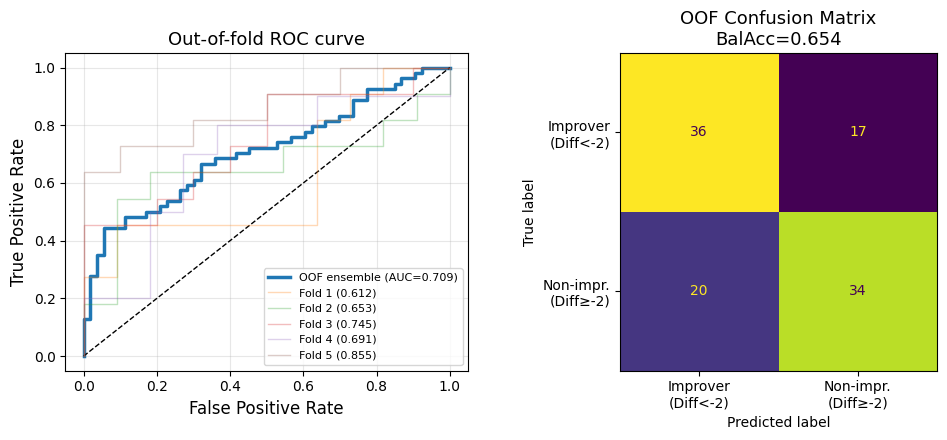

Saved → reports/pipeline_v2/roc_confusion.png


In [21]:
# ── 9a. OOF ROC curve + Confusion Matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ROC
fpr_oof, tpr_oof, _ = roc_curve(y_full[valid], oof_proba[valid])
axes[0].plot(fpr_oof, tpr_oof, lw=2.5,
             label=f'OOF ensemble (AUC={oof_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Out-of-fold ROC curve', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Per-fold ROC
mean_fpr = np.linspace(0,1,200)
tprs_list = []
for fold_i, (tr, te) in enumerate(
        outer_cv.split(X_eeg, y_full, groups=groups), 1):
    fpr_f, tpr_f, _ = roc_curve(y_full[te], oof_proba[te])
    auc_f = roc_auc_score(y_full[te], oof_proba[te])
    axes[0].plot(fpr_f, tpr_f, alpha=0.3, lw=1,
                 label=f'Fold {fold_i} ({auc_f:.3f})')
    tprs_list.append(np.interp(mean_fpr, fpr_f, tpr_f))
mean_tpr = np.mean(tprs_list, axis=0); mean_tpr[-1] = 1.0
axes[0].legend(fontsize=8, loc='lower right')

# Confusion matrix
oof_cm = confusion_matrix(y_full[valid], oof_pred)
ConfusionMatrixDisplay(oof_cm,
    display_labels=['Improver\n(Diff<-2)', 'Non-impr.\n(Diff≥-2)']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'OOF Confusion Matrix\nBalAcc={oof_ba:.3f}', fontsize=13)

plt.tight_layout()
fig.savefig(OUT_DIR / 'roc_confusion.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/roc_confusion.png')

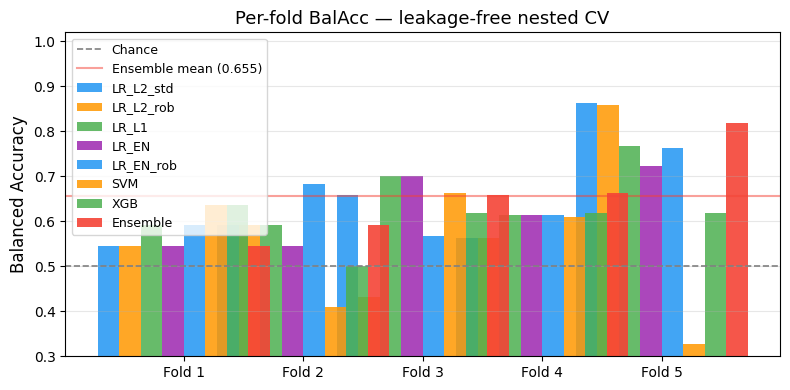

In [22]:
# ── 9b. Per-fold BalAcc bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

x    = np.arange(N_OUTER_SPLITS)
w    = 0.18
cols = ['#2196F3','#FF9800','#4CAF50','#9C27B0']

for k, mn in enumerate(model_names):
    m_bas = [r['indiv'][mn]['ba'] for r in fold_results]
    ax.bar(x + k*w, m_bas, w, label=mn, alpha=0.85, color=cols[k % len(cols)])

ens_bas = [r['ba'] for r in fold_results]
ax.bar(x + len(model_names)*w, ens_bas, w, label='Ensemble',
       color='#F44336', alpha=0.9)

ax.axhline(0.5, ls='--', color='gray', lw=1.2, label='Chance')
ax.axhline(np.mean(bas), ls='-', color='#F44336', lw=1.5, alpha=0.5,
           label=f'Ensemble mean ({np.mean(bas):.3f})')
ax.set_xticks(x + (len(model_names))*w/2)
ax.set_xticklabels([f'Fold {i}' for i in range(1, N_OUTER_SPLITS+1)])
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_title('Per-fold BalAcc — leakage-free nested CV', fontsize=13)
ax.set_ylim(0.3, 1.02)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'per_fold_balacc.png', dpi=200)
plt.show()

## 10. SHAP Interpretability

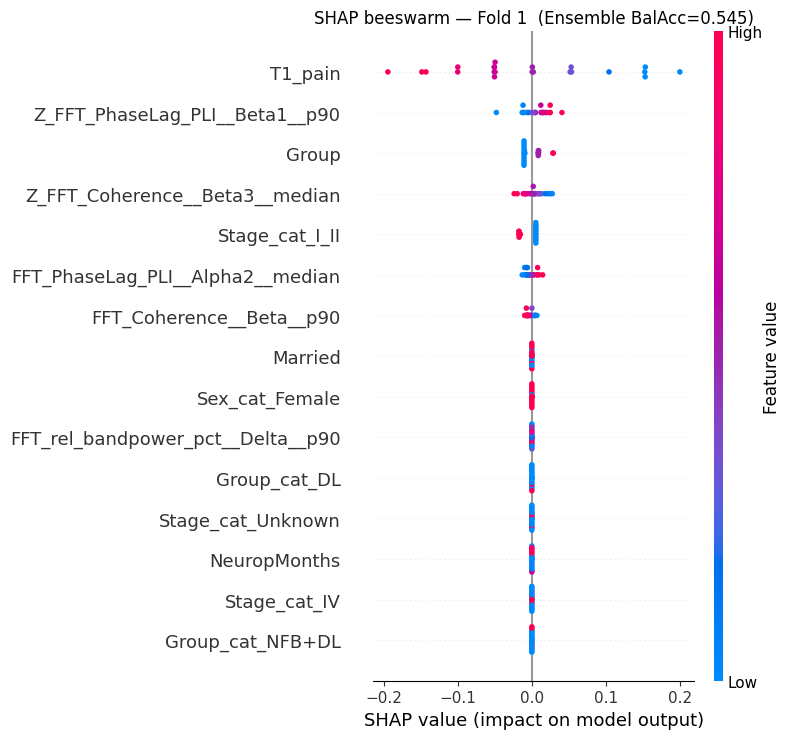

Saved → reports/pipeline_v2/shap/fold1_beeswarm.png


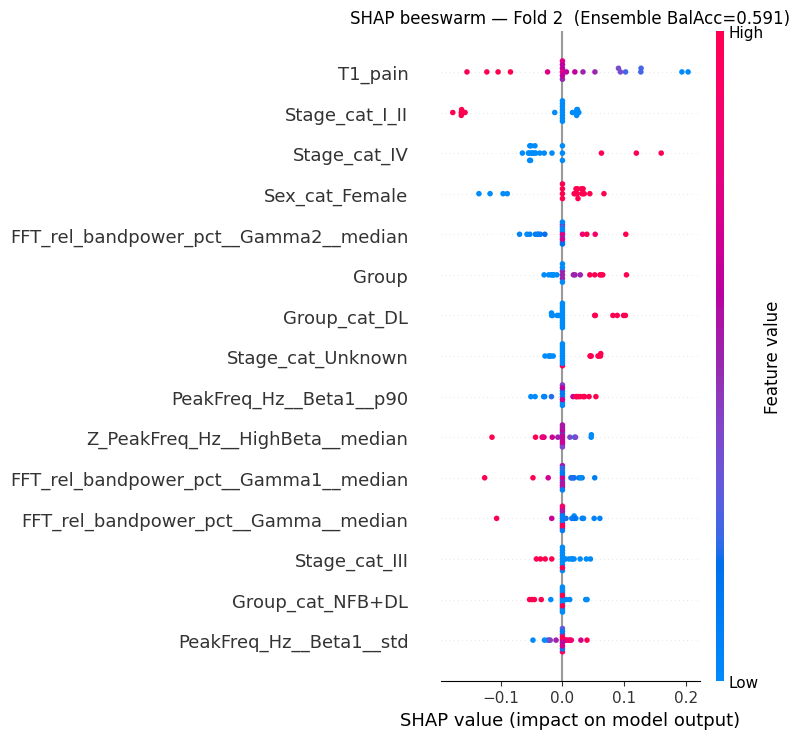

Saved → reports/pipeline_v2/shap/fold2_beeswarm.png


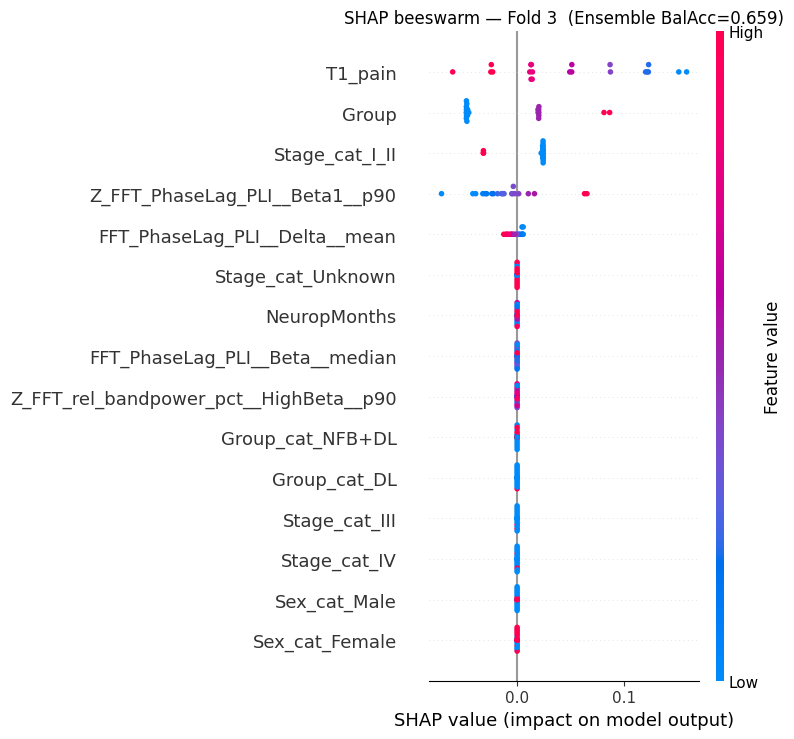

Saved → reports/pipeline_v2/shap/fold3_beeswarm.png


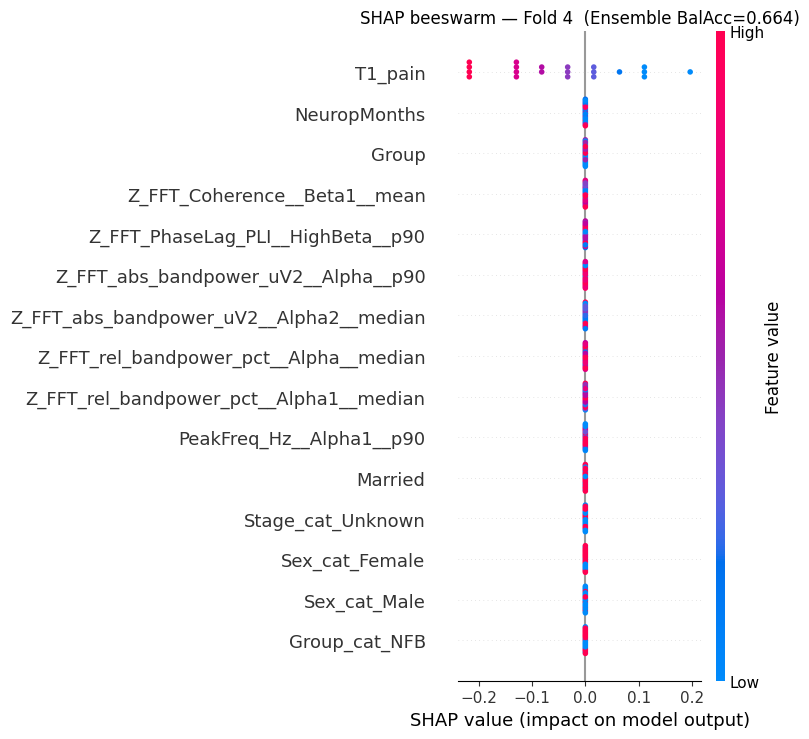

Saved → reports/pipeline_v2/shap/fold4_beeswarm.png


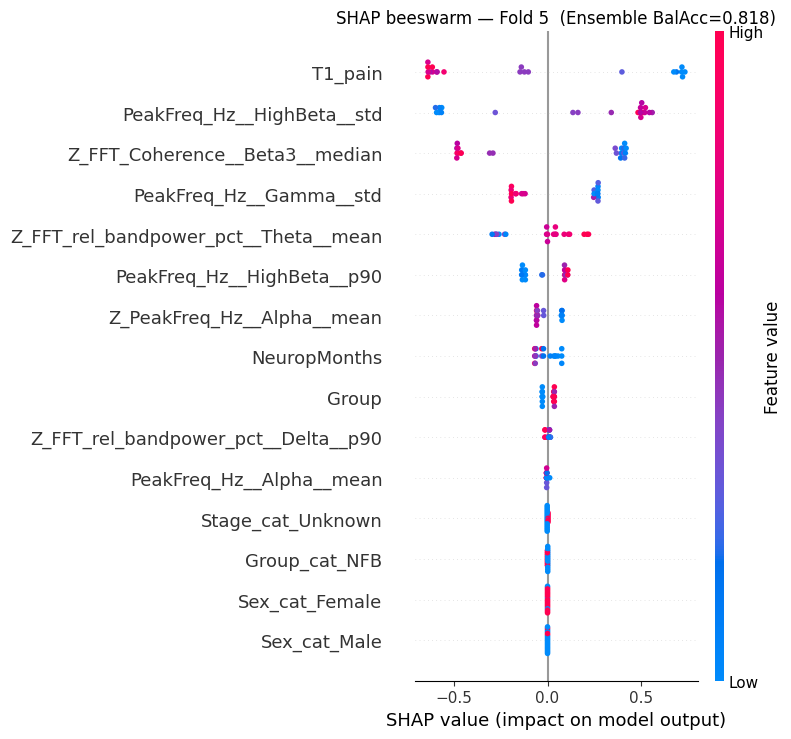

Saved → reports/pipeline_v2/shap/fold5_beeswarm.png


In [23]:
# ── 10a. Per-fold SHAP beeswarm plots ────────────────────────────────────────
if not HAS_SHAP:
    print('shap not installed — skipping')
else:
    for k, (sv, X_imp, feat_names) in enumerate(
            zip(fold_shap_vals, fold_shap_X, fold_shap_names), 1):
        if sv is None:
            print(f'Fold {k}: SHAP unavailable')
            continue
        X_df = pd.DataFrame(X_imp, columns=feat_names)
        plt.figure(figsize=(9, max(4, len(feat_names)*0.42)))
        shap.summary_plot(sv, X_df, show=False, max_display=15)
        plt.title(f'SHAP beeswarm — Fold {k}  '
                  f'(Ensemble BalAcc={fold_results[k-1]["ba"]:.3f})')
        plt.tight_layout()
        out_path = SHAP_DIR / f'fold{k}_beeswarm.png'
        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved → {out_path}')

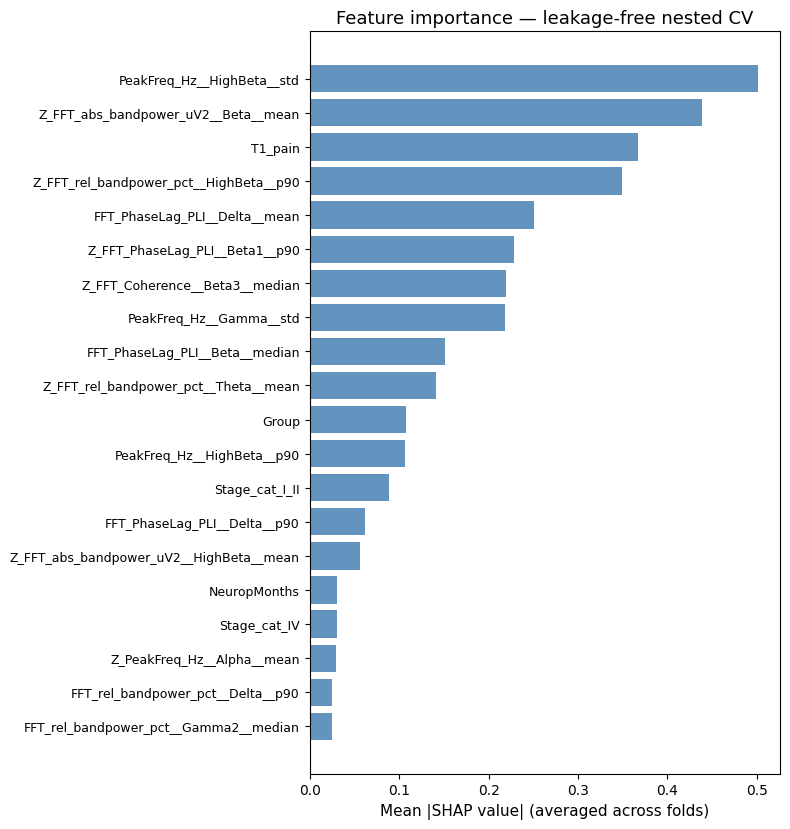

Saved → reports/pipeline_v2/shap/aggregated_shap_bar.png


In [14]:
# ── 10b. Aggregated mean |SHAP| bar chart ────────────────────────────────────
if not HAS_SHAP:
    print('shap not installed — skipping')
else:
    feat_mean_abs = defaultdict(list)
    for sv, feat_names in zip(fold_shap_vals, fold_shap_names):
        if sv is None:
            continue
        for j, fn in enumerate(feat_names):
            feat_mean_abs[fn].append(float(np.abs(sv[:, j]).mean()))

    agg = sorted(
        {f: np.mean(v) for f, v in feat_mean_abs.items()}.items(),
        key=lambda kv: kv[1], reverse=True)[:20]

    if agg:
        names_p, vals_p = zip(*agg)
        fig, ax = plt.subplots(figsize=(8, max(4, len(names_p)*0.42)))
        ax.barh(range(len(names_p)), vals_p[::-1], color='steelblue', alpha=0.85)
        ax.set_yticks(range(len(names_p)))
        ax.set_yticklabels(names_p[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP value| (averaged across folds)', fontsize=11)
        ax.set_title('Feature importance — leakage-free nested CV', fontsize=13)
        plt.tight_layout()
        out_path = SHAP_DIR / 'aggregated_shap_bar.png'
        fig.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved → {out_path}')

## 11. Save Results

In [15]:
# ── 11. Export results to CSV ─────────────────────────────────────────────────
rows_out = []
for r in fold_results:
    base = {
        'fold':        r['fold'],
        'n_train':     r['n_train'],
        'n_test':      r['n_test'],
        'n_eeg_feats': r['n_eeg'],
        'ensemble_ba': r['ba'],
        'ensemble_auc':r['auc'],
        'ensemble_f1': r['f1'],
        'sensitivity': r['sensitivity'],
        'specificity': r['specificity'],
        'selected_eeg_features': ' | '.join(r['sel_feats']),
    }
    for mn in model_names:
        base[f'{mn}_ba']  = r['indiv'][mn]['ba']
        base[f'{mn}_auc'] = r['indiv'][mn]['auc']
    rows_out.append(base)

results_df = pd.DataFrame(rows_out)
results_df.to_csv(OUT_DIR / 'cv_results.csv', index=False)
print(results_df.to_string(index=False))
print(f'\nSaved → {OUT_DIR}/cv_results.csv')

# Summary row
summary = {
    'fold': 'MEAN±SD',
    'ensemble_ba':  f'{np.mean(bas):.3f}±{np.std(bas):.3f}',
    'ensemble_auc': f'{np.mean(aucs):.3f}±{np.std(aucs):.3f}',
    'OOF_ba':  f'{oof_ba:.3f}',
    'OOF_auc': f'{oof_auc:.3f}',
}
print('\nSummary:', summary)

 fold  n_train  n_test  n_eeg_feats  ensemble_ba  ensemble_auc  ensemble_f1  sensitivity  specificity                                                                                                                                                                                                                                                                     selected_eeg_features   SVM_ba  SVM_auc  LogReg_ba  LogReg_auc   XGB_ba  XGB_auc
    1       85      22            8     0.636364      0.636364     0.555556     0.454545     0.818182                  Z_FFT_PhaseLag_PLI__Beta3__mean | FFT_rel_bandpower_pct__Delta__p90 | Z_FFT_abs_bandpower_uV2__HighBeta__mean | PeakFreq_Hz__Theta__mean | FFT_Coherence__Beta__p90 | Z_FFT_Coherence__Beta3__median | FFT_PhaseLag_PLI__Alpha2__median | Z_FFT_PhaseLag_PLI__Beta1__p90 0.636364 0.619835   0.590909    0.694215 0.636364 0.607438
    2       85      22            8     0.454545      0.504132     0.500000     0.545455     0.363636             